In [2]:
import pandas as pd

dataset = pd.read_csv("../datasets/penguins.csv")

feature_names = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
]
target_name = "Body Mass (g)"

dataset = dataset[feature_names + [target_name]].dropna(axis="rows", how="any")
dataset = dataset.sample(frac=1, random_state=0).reset_index(drop=True)
data, target = dataset[feature_names], dataset[target_name]

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

tree = DecisionTreeRegressor(random_state=0)
forest = RandomForestRegressor(random_state=0)

cv_results_tree = cross_validate(tree, data, target, cv=10, return_train_score=True)
cv_results_forest = cross_validate(forest, data, target, cv=10, return_train_score=True)

In [4]:
count = 0
for test_score_tree, test_score_forest in zip(cv_results_tree["test_score"], cv_results_forest["test_score"]):
    count += test_score_forest > test_score_tree
print(f"Forest is {count} / 10 folds better than tree")

Forest is 10 / 10 folds better than tree


In [5]:
rf_5_trees = RandomForestRegressor(n_estimators=5, random_state=0)
rf_100_trees = RandomForestRegressor(n_estimators=100, random_state=0)
cv = 10

cv_results_rf_5_trees = cross_validate(
    rf_5_trees, data, target, cv=cv, return_train_score=True
)
cv_results_rf_100_trees = cross_validate(
    rf_100_trees, data, target, cv=cv, return_train_score=True
)

In [6]:
print(
    "Random forest with 100 trees is better than a random forest with 5 trees for "
    f"{sum(cv_results_rf_100_trees['test_score'] > cv_results_rf_5_trees['test_score'])} "
    "CV iterations out of 10"
)

Random forest with 100 trees is better than a random forest with 5 trees for 9 CV iterations out of 10


In [7]:
print(
    "Scores for random forest with 5 trees: "
    f"train: {cv_results_rf_5_trees['train_score'].mean():.3f} +/- "
    f"{cv_results_rf_5_trees['train_score'].std():.3f}, "
    f"test: {cv_results_rf_5_trees['test_score'].mean():.3f} +/- "
    f"{cv_results_rf_5_trees['test_score'].std():.3f}"
)
print(    
    "Scores for random forest with 100 trees: "
    f"train: {cv_results_rf_100_trees['train_score'].mean():.3f} +/- "
    f"{cv_results_rf_100_trees['train_score'].std():.3f}, "
    f"test: {cv_results_rf_100_trees['test_score'].mean():.3f} +/- "
    f"{cv_results_rf_100_trees['test_score'].std():.3f}"
  )

Scores for random forest with 5 trees: train: 0.950 +/- 0.003, test: 0.767 +/- 0.074
Scores for random forest with 100 trees: train: 0.972 +/- 0.001, test: 0.804 +/- 0.045


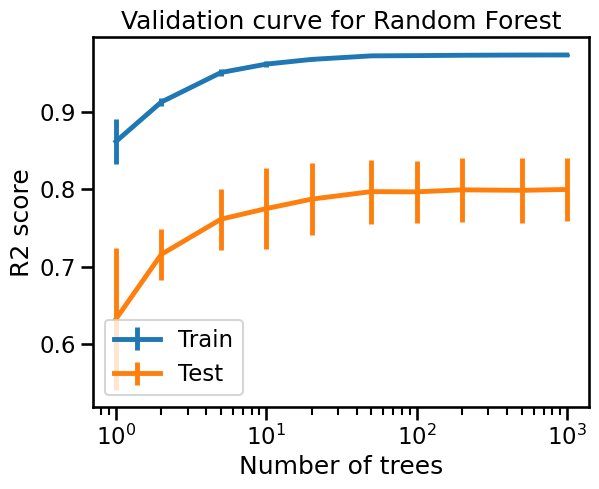

In [8]:
import numpy as np
n_estimators = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1_000])

from sklearn.model_selection import ValidationCurveDisplay

display = ValidationCurveDisplay.from_estimator(
    forest,
    data,
    target,
    param_name="n_estimators",
    param_range=n_estimators,
    scoring="r2",
    score_name="R2 score",
    std_display_style="errorbar",
    n_jobs=2
)

_ = display.ax_.set(
    xlabel="Number of trees",
    title="Validation curve for Random Forest",
)

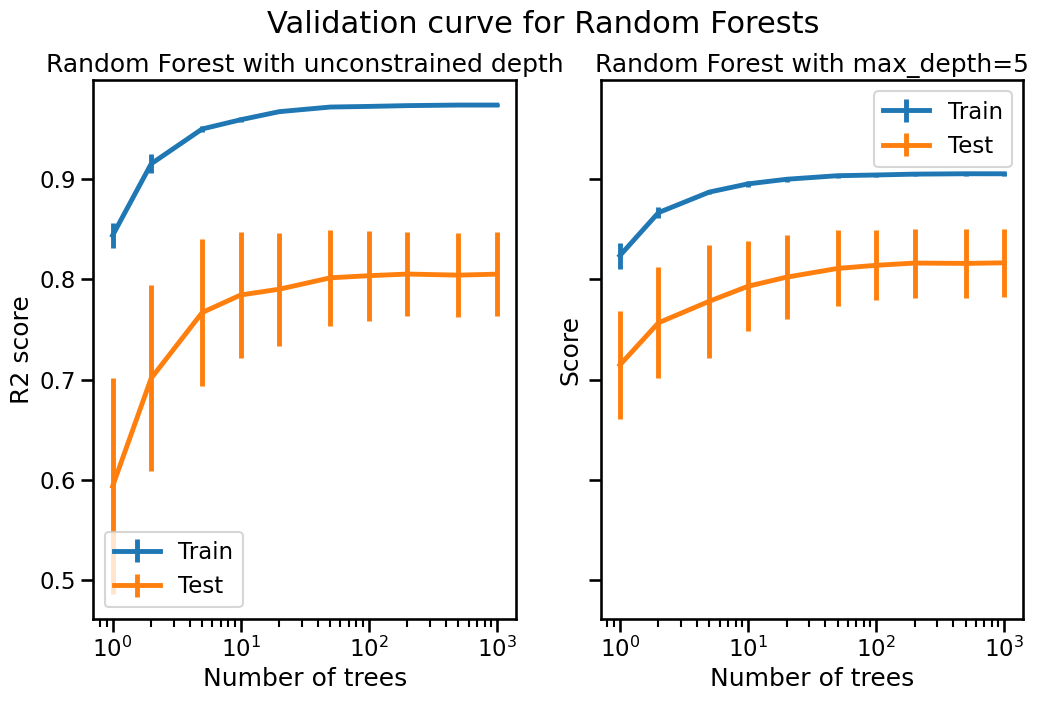

In [9]:
import matplotlib.pyplot as plt

rf_shallow = RandomForestRegressor(max_depth=5, random_state=0)

fig, axs = plt.subplots(ncols=2, figsize=(12, 7),  sharey=True)
ValidationCurveDisplay.from_estimator(
    forest,
    data,
    target,
    param_name="n_estimators",
    param_range=n_estimators,
    scoring="r2",
    score_name="R2 score",
    std_display_style="errorbar",
    cv=cv,
    n_jobs=2,
    ax=axs[0]
)
ValidationCurveDisplay.from_estimator(
    rf_shallow,
    data,
    target,
    param_name="n_estimators",
    param_range=n_estimators,
    std_display_style="errorbar",
    cv=cv,
    n_jobs=2,
    ax=axs[1],
)

axs[0].set(
    xlabel="Number of trees",
    title="Random Forest with unconstrained depth",
)
axs[1].set(
    xlabel="Number of trees",
    title="Random Forest with max_depth=5",
)
_ = fig.suptitle("Validation curve for Random Forests")

In [10]:
rf_1_tree = RandomForestRegressor(n_estimators=1, random_state=0)
cv_results_tree = cross_validate(
    rf_1_tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]

array([0.83120264, 0.83309064, 0.83195043, 0.84834224, 0.85790323,
       0.86235297, 0.84791111, 0.85183089, 0.82241954, 0.85045978])

In [11]:
tree = DecisionTreeRegressor(random_state=0)
cv_results_tree = cross_validate(
    tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [12]:
rf_1_tree = RandomForestRegressor(n_estimators=1, bootstrap=False, random_state=0)
cross_validate(rf_1_tree, data, target, cv=cv, return_train_score=True)["train_score"]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

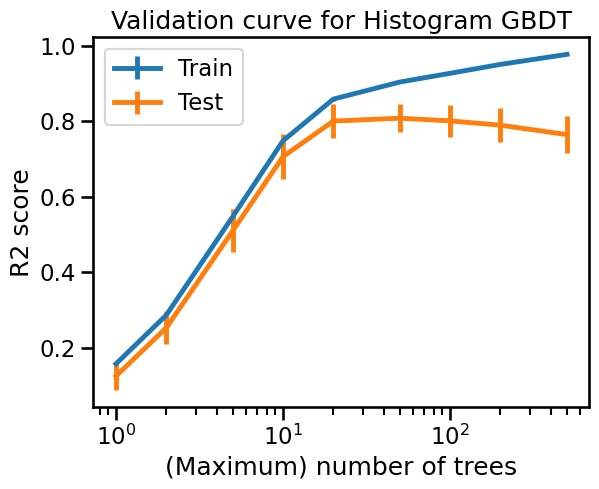

In [14]:
max_iters = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
from sklearn.ensemble import HistGradientBoostingRegressor

hgbdt = HistGradientBoostingRegressor(random_state=0)
max_iters = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])

disp = ValidationCurveDisplay.from_estimator(
    hgbdt,
    data,
    target,
    param_name="max_iter",
    param_range=max_iters,
    scoring="r2",  # note: this is already the default for regression
    score_name="R2 score",
    std_display_style="errorbar",
    cv=cv,
    n_jobs=2,
)

_ = disp.ax_.set(
    xlabel="(Maximum) number of trees",
    title="Validation curve for Histogram GBDT",
)

In [15]:
hgbdt = HistGradientBoostingRegressor(early_stopping=True, random_state=0)
cv_results_hgbdt = cross_validate(
    hgbdt, data, target, cv=cv, return_train_score=True, return_estimator=True
)
cv_results_hgbdt["train_score"].mean(), cv_results_hgbdt["train_score"].std()

(np.float64(0.8802093174685013), np.float64(0.009772033922083758))

In [16]:
cv_results_hgbdt["test_score"].mean(), cv_results_hgbdt["test_score"].std()

(np.float64(0.8075456252855009), np.float64(0.030400979794505564))

In [17]:
for idx, est in enumerate(cv_results_hgbdt["estimator"]):
    print(
        f"For CV iteration {idx + 1}, {est.n_iter_} trees were built"
    )

For CV iteration 1, 60 trees were built
For CV iteration 2, 50 trees were built
For CV iteration 3, 46 trees were built
For CV iteration 4, 29 trees were built
For CV iteration 5, 33 trees were built
For CV iteration 6, 33 trees were built
For CV iteration 7, 36 trees were built
For CV iteration 8, 31 trees were built
For CV iteration 9, 24 trees were built
For CV iteration 10, 23 trees were built
